In [50]:
import sys, os
import numpy as np

import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
from torch.optim import AdamW

from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

sys.path.append(os.path.dirname(os.getcwd()))
from Predictor import Predictor
from PartialVAE import PartialVAE
from Flow import Flow
from train_utils import (
    set_seed,
    train_predictor,
    train_VAE,
    train_Flow,
    run_feature_acquisition,
)

In [51]:
SEED = 9750
np.random.seed(SEED)
torch.manual_seed(SEED)

In [52]:
ROOT_DIR = os.path.dirname(os.getcwd())
DATA_DIR = os.path.join(ROOT_DIR, "data", "metabric")

X_train = torch.load(f"{DATA_DIR}/X_train_cdf.pt").float()
y_train = torch.load(f"{DATA_DIR}/y_train.pt").long()

X_val   = torch.load(f"{DATA_DIR}/X_val_cdf.pt").float()
y_val   = torch.load(f"{DATA_DIR}/y_val.pt").long()

X_test = torch.load(f"{DATA_DIR}/X_test_cdf.pt").float()
y_test = torch.load(f"{DATA_DIR}/y_test.pt").long()

In [53]:
batch_size = 128
epochs = 100
lr = 0.0003
weight_decay = 1e-4
D = 12  # feature 개수 고정

predictor = Predictor(in_dim=12, hidden_dim=150, out_dim=6, num_hidden=2)
optimizer = AdamW(predictor.parameters(), lr=lr, weight_decay=weight_decay)
criterion = nn.CrossEntropyLoss()

train_ds = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)

train_predictor(
    predictor=predictor,
    train_loader=train_loader,
    X_val=X_val,
    y_val=y_val,
    D=D,
    epochs=epochs,
    optimizer=optimizer,
    criterion=criterion
)

Epoch 1/100 | train_loss=1.7964 | val_loss=1.6907 | val_acc=0.4074 | lr=0.000300
Epoch 2/100 | train_loss=1.4999 | val_loss=1.4796 | val_acc=0.5397 | lr=0.000300
Epoch 3/100 | train_loss=1.3319 | val_loss=1.3472 | val_acc=0.4709 | lr=0.000300
Epoch 4/100 | train_loss=1.2545 | val_loss=1.2180 | val_acc=0.6085 | lr=0.000300
Epoch 5/100 | train_loss=1.1923 | val_loss=1.1803 | val_acc=0.5979 | lr=0.000300
Epoch 6/100 | train_loss=1.1206 | val_loss=1.1053 | val_acc=0.6190 | lr=0.000300
Epoch 7/100 | train_loss=1.0914 | val_loss=1.0629 | val_acc=0.6296 | lr=0.000300
Epoch 8/100 | train_loss=1.0904 | val_loss=1.1686 | val_acc=0.5661 | lr=0.000300
Epoch 9/100 | train_loss=1.0507 | val_loss=1.0930 | val_acc=0.5714 | lr=0.000300
Epoch 10/100 | train_loss=1.0331 | val_loss=1.0852 | val_acc=0.6402 | lr=0.000300
Epoch 11/100 | train_loss=1.0260 | val_loss=1.1133 | val_acc=0.6032 | lr=0.000300
Epoch 12/100 | train_loss=1.0131 | val_loss=0.9491 | val_acc=0.6614 | lr=0.000300
Epoch 13/100 | train_loss

In [54]:
batch_size = 256
epochs = 100
lr = 1e-3
weight_decay = 1e-4

pvae = PartialVAE(
    input_type="continuous",
    num_con_features=12,
    num_cat_features=0,
    hidden_dim_con=150,
    most_categories=max(1, 0),   # 내부 차원 계산을 위해 최소 1
    c_dim=6,
    hid_enc=100,
    hid_dec=100,
    latent_dim=30,
    num_hidden_emb=2,
    num_hidden_enc=2,
    num_hidden_dec=2
)
optimizer = AdamW(pvae.parameters(), lr=lr, weight_decay=weight_decay)
criterion = nn.CrossEntropyLoss()

train_VAE(
    generator=pvae,
    train_loader=train_loader,
    X_val=X_val,
    D=D, # feature 개수
    epochs=epochs,
    optimizer=optimizer,
    obs_sigma=0.2,
    lr_factor=0.2,
    cooldown=0,
    min_lr=1e-7,
    scheduler_patience=5
)

[PVAE ep 01] train_loss=20.8011  train_KL=8.1500  train_NLL_X=12.6511 | val_loss=14.2957  val_KL=3.1719  val_NLL_X=11.1238 | lr=0.001000
[PVAE ep 02] train_loss=15.5558  train_KL=5.9543  train_NLL_X=9.6015 | val_loss=13.0603  val_KL=3.5989  val_NLL_X=9.4614 | lr=0.001000
[PVAE ep 03] train_loss=13.3896  train_KL=5.1079  train_NLL_X=8.2817 | val_loss=12.3374  val_KL=4.4711  val_NLL_X=7.8663 | lr=0.001000
[PVAE ep 04] train_loss=12.2578  train_KL=4.6721  train_NLL_X=7.5857 | val_loss=12.5284  val_KL=4.3882  val_NLL_X=8.1402 | lr=0.001000
[PVAE ep 05] train_loss=11.7361  train_KL=4.2791  train_NLL_X=7.4569 | val_loss=11.5160  val_KL=3.8942  val_NLL_X=7.6218 | lr=0.001000
[PVAE ep 06] train_loss=11.2719  train_KL=4.0199  train_NLL_X=7.2520 | val_loss=11.0774  val_KL=3.7167  val_NLL_X=7.3607 | lr=0.001000
[PVAE ep 07] train_loss=10.7748  train_KL=3.7556  train_NLL_X=7.0192 | val_loss=10.8807  val_KL=3.5740  val_NLL_X=7.3067 | lr=0.001000
[PVAE ep 08] train_loss=10.4109  train_KL=3.3698  tra

Step 1/12 | Acc: 0.4398
Step 2/12 | Acc: 0.4817
Step 3/12 | Acc: 0.5393
Step 4/12 | Acc: 0.5864
Step 5/12 | Acc: 0.6283
Step 6/12 | Acc: 0.6440
Step 7/12 | Acc: 0.6492
Step 8/12 | Acc: 0.6754
Step 9/12 | Acc: 0.7120
Step 10/12 | Acc: 0.7173
Step 11/12 | Acc: 0.6859
Step 12/12 | Acc: 0.6754
전체 평균: 0.61954623
표준편차: 0.0
acquisition 별 평균): [0.43979058 0.4816754  0.539267   0.58638746 0.62827224 0.6439791
 0.6492147  0.6753927  0.7120419  0.71727747 0.68586385 0.6753927 ]


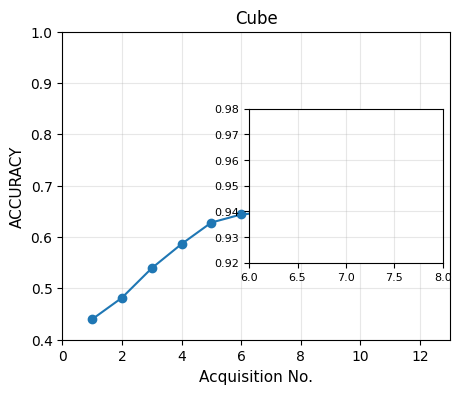

Mean ACC over all acquisitions = 0.6195


In [70]:
predictor.eval()
N = X_test.size(0)
D = X_test.size(1)
x_np = X_test.cpu().numpy()
m_np = np.zeros((N, D), dtype=np.float32)

result = []

accs = run_feature_acquisition(
    predictor=predictor,
    generator=pvae,
    X_test=X_test,
    y_test=y_test,
    x_np=x_np,
    m_np=m_np,
    D=D,
    num_samples=10,
    alpha=1,
    gamma=1.0
)

result.append(accs)

result = np.array(result, dtype=np.float32)

num_runs, D = result.shape
row_means = result.mean(axis=1)
overall_mean = row_means.mean()

std = row_means.std()

col_means = result.mean(axis=0)

print("전체 평균:", overall_mean)
print("표준편차:", std)
print("acquisition 별 평균):", col_means)

# 시각화
xs = np.arange(1, D + 1)

plt.figure(figsize=(5, 4))
plt.plot(xs, col_means, marker='o')
plt.xlabel('Acquisition No.', fontsize=11)
plt.ylabel('ACCURACY', fontsize=11)
plt.title('Cube', fontsize=12)
plt.xticks(np.arange(0, D+1, 2))
plt.xlim(0, D + 1)
plt.ylim(0.4, 1.0)
plt.grid(True, alpha=0.3)

# 확대 영역
ax = plt.gca()
axins = inset_axes(ax, width="50%", height="50%", loc='center right')

axins.plot(xs, col_means, marker='o')
axins.set_xlim(6, 8)
axins.set_ylim(0.92, 0.98)
axins.grid(True, alpha=0.3)
axins.tick_params(labelsize=8)

plt.show()

mean_acc = np.nanmean(col_means)
print(f"Mean ACC over all acquisitions = {mean_acc:.4f}")

전체 평균: 0.60209423
표준편차: 0.0
acquisition 별 평균): [0.42408377 0.5026178  0.5183246  0.565445   0.5968586  0.63874346
 0.63874346 0.6753927  0.6701571  0.65968585 0.65968585 0.6753927 ]


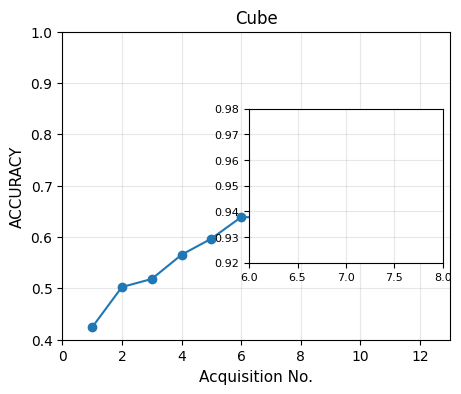

Mean ACC over all acquisitions = 0.6021


In [56]:
result = np.array(result, dtype=np.float32)

num_runs, D = result.shape
row_means = result.mean(axis=1)
overall_mean = row_means.mean()

std = row_means.std()

col_means = result.mean(axis=0)

print("전체 평균:", overall_mean)
print("표준편차:", std)
print("acquisition 별 평균):", col_means)

# 시각화
xs = np.arange(1, D + 1)

plt.figure(figsize=(5, 4))
plt.plot(xs, col_means, marker='o')
plt.xlabel('Acquisition No.', fontsize=11)
plt.ylabel('ACCURACY', fontsize=11)
plt.title('Cube', fontsize=12)
plt.xticks(np.arange(0, D+1, 2))
plt.xlim(0, D + 1)
plt.ylim(0.4, 1.0)
plt.grid(True, alpha=0.3)

# 확대 영역
ax = plt.gca()
axins = inset_axes(ax, width="50%", height="50%", loc='center right')

axins.plot(xs, col_means, marker='o')
axins.set_xlim(6, 8)
axins.set_ylim(0.92, 0.98)
axins.grid(True, alpha=0.3)
axins.tick_params(labelsize=8)

plt.show()

mean_acc = np.nanmean(col_means)
print(f"Mean ACC over all acquisitions = {mean_acc:.4f}")